In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
DATA_PATH = "D:\\HealthForecastAI\\ml\\data\\raw\\diabetic_data.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# identify treatment related columns

In [3]:
print("Total columns:", len(df.columns))

for col in df.columns:
    print(col)

Total columns: 50
encounter_id
patient_nbr
race
gender
age
weight
admission_type_id
discharge_disposition_id
admission_source_id
time_in_hospital
payer_code
medical_specialty
num_lab_procedures
num_procedures
num_medications
number_outpatient
number_emergency
number_inpatient
diag_1
diag_2
diag_3
number_diagnoses
max_glu_serum
A1Cresult
metformin
repaglinide
nateglinide
chlorpropamide
glimepiride
acetohexamide
glipizide
glyburide
tolbutamide
pioglitazone
rosiglitazone
acarbose
miglitol
troglitazone
tolazamide
examide
citoglipton
insulin
glyburide-metformin
glipizide-metformin
glimepiride-pioglitazone
metformin-rosiglitazone
metformin-pioglitazone
change
diabetesMed
readmitted


# Treatment exposure summary 

In [4]:
medication_columns = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
]

available_medications = [
    col for col in medication_columns if col in df.columns
]

print("Medication columns found:", len(available_medications))
print(available_medications)

Medication columns found: 23
['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


# Medical exposure count

In [5]:
medication_exposure = {}

for medication in available_medications:
    medication_exposure[medication] = (
        ~df[medication].isin(["No", ""])
    ).sum()

medication_exposure_df = (
    pd.Series(medication_exposure)
    .sort_values(ascending=False)
    .reset_index()
)

medication_exposure_df.columns = ["medication", "patient_count"]

medication_exposure_df

,medication,patient_count
0,insulin,54383
1,metformin,19988
2,glipizide,12686
3,glyburide,10650
4,pioglitazone,7328
5,rosiglitazone,6365
6,glimepiride,5191
7,repaglinide,1539
8,glyburide-metformin,706
9,nateglinide,703


see the distribution of column

In [6]:
df["readmitted"].value_counts(dropna=False)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [7]:
df["readmitted"].value_counts(normalize=True, dropna=False) * 100

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64

# medication wise outcome analysis

In [8]:
# Create medication-wise outcome analysis

outcome_analysis = []

for medication in available_medications:
    # Patients who received/used the medication
    medication_mask = ~df[medication].isin(["No", ""])

    medication_df = df.loc[medication_mask].copy()

    total_patients = len(medication_df)

    if total_patients == 0:
        continue

    no_readmission = (medication_df["readmitted"] == "NO").sum()
    readmitted_after_30 = (medication_df["readmitted"] == ">30").sum()
    readmitted_within_30 = (medication_df["readmitted"] == "<30").sum()

    outcome_analysis.append({
        "medication": medication,
        "total_patients": total_patients,
        "no_readmission": no_readmission,
        "readmitted_30_plus": readmitted_after_30,
        "readmitted_under_30": readmitted_within_30,
        "no_readmission_rate": no_readmission / total_patients * 100,
        "readmission_30_plus_rate": readmitted_after_30 / total_patients * 100,
        "readmission_under_30_rate": readmitted_within_30 / total_patients * 100,
    })

medication_outcome_df = pd.DataFrame(outcome_analysis)

medication_outcome_df = medication_outcome_df.sort_values(
    "total_patients",
    ascending=False
)

medication_outcome_df

,medication,total_patients,no_readmission,readmitted_30_plus,readmitted_under_30,no_readmission_rate,readmission_30_plus_rate,readmission_under_30_rate
15,insulin,54383,28186,19596,6601,51.828696,36.033319,12.137984
0,metformin,19988,11343,6706,1939,56.749049,33.550130,9.700820
6,glipizide,12686,6504,4730,1452,51.269116,37.285196,11.445688
7,glyburide,10650,5800,3718,1132,54.460094,34.910798,10.629108
9,pioglitazone,7328,3797,2757,774,51.814956,37.622817,10.562227
10,rosiglitazone,6365,3291,2409,665,51.704635,37.847604,10.447761
4,glimepiride,5191,2754,1907,530,53.053362,36.736660,10.209979
1,repaglinide,1539,694,640,205,45.094217,41.585445,13.320338
16,glyburide-metformin,706,370,258,78,52.407932,36.543909,11.048159
2,nateglinide,703,361,262,80,51.351351,37.268848,11.379801


# effectiveness metric
No-readmission rate = percentage of patients receiving a medication who were not readmitted.

In [9]:
medication_effectiveness = medication_outcome_df[
    [
        "medication",
        "total_patients",
        "no_readmission_rate",
        "readmission_30_plus_rate",
        "readmission_under_30_rate",
    ]
].copy()

medication_effectiveness = medication_effectiveness.sort_values(
    "no_readmission_rate",
    ascending=False
)

medication_effectiveness

,medication,total_patients,no_readmission_rate,readmission_30_plus_rate,readmission_under_30_rate
19,metformin-rosiglitazone,2,100.000000,0.000000,0.000000
20,metformin-pioglitazone,1,100.000000,0.000000,0.000000
14,tolazamide,39,66.666667,25.641026,7.692308
8,tolbutamide,23,65.217391,30.434783,4.347826
0,metformin,19988,56.749049,33.550130,9.700820
3,chlorpropamide,86,54.651163,39.534884,5.813953
7,glyburide,10650,54.460094,34.910798,10.629108
4,glimepiride,5191,53.053362,36.736660,10.209979
16,glyburide-metformin,706,52.407932,36.543909,11.048159
15,insulin,54383,51.828696,36.033319,12.137984


# We used no-readmission rate as an observational outcome indicator to compare treatment outcomes across medications.”

In [10]:
reliable_medication_analysis = medication_effectiveness[
    medication_effectiveness["total_patients"] >= 100
].copy()

reliable_medication_analysis

,medication,total_patients,no_readmission_rate,readmission_30_plus_rate,readmission_under_30_rate
0,metformin,19988,56.749049,33.550130,9.700820
7,glyburide,10650,54.460094,34.910798,10.629108
4,glimepiride,5191,53.053362,36.736660,10.209979
16,glyburide-metformin,706,52.407932,36.543909,11.048159
15,insulin,54383,51.828696,36.033319,12.137984
9,pioglitazone,7328,51.814956,37.622817,10.562227
10,rosiglitazone,6365,51.704635,37.847604,10.447761
2,nateglinide,703,51.351351,37.268848,11.379801
6,glipizide,12686,51.269116,37.285196,11.445688
1,repaglinide,1539,45.094217,41.585445,13.320338


# visualization

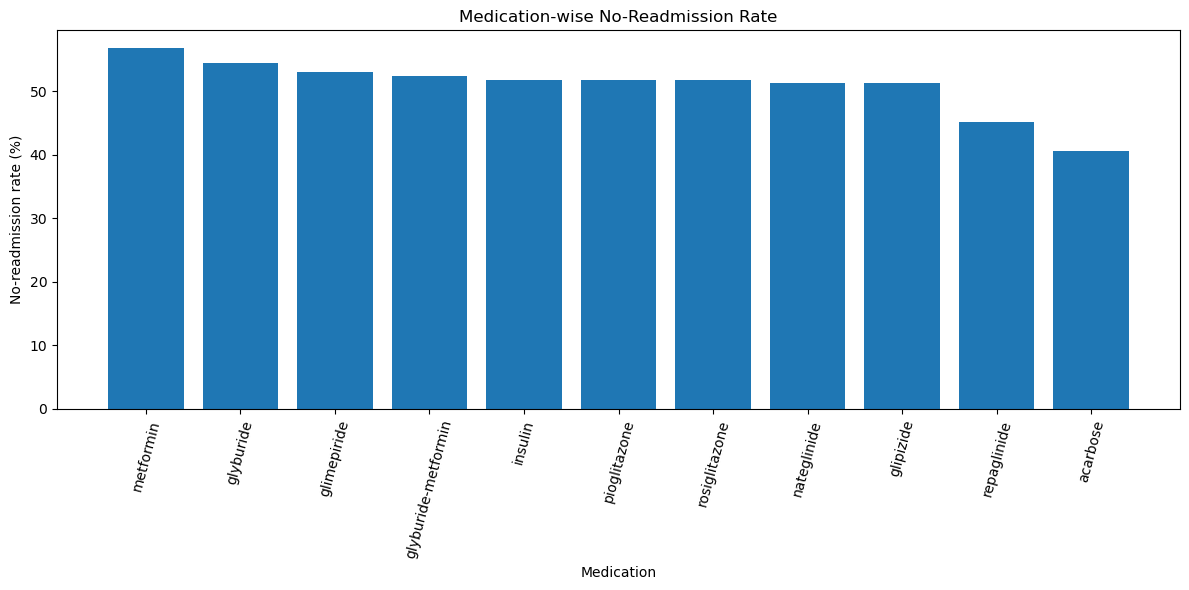

In [11]:
plt.figure(figsize=(12, 6))

plt.bar(
    reliable_medication_analysis["medication"],
    reliable_medication_analysis["no_readmission_rate"]
)

plt.xlabel("Medication")
plt.ylabel("No-readmission rate (%)")
plt.title("Medication-wise No-Readmission Rate")
plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

In [12]:
reliable_medication_analysis = medication_effectiveness[
    medication_effectiveness["total_patients"] >= 100
].copy()

reliable_medication_analysis

,medication,total_patients,no_readmission_rate,readmission_30_plus_rate,readmission_under_30_rate
0,metformin,19988,56.749049,33.550130,9.700820
7,glyburide,10650,54.460094,34.910798,10.629108
4,glimepiride,5191,53.053362,36.736660,10.209979
16,glyburide-metformin,706,52.407932,36.543909,11.048159
15,insulin,54383,51.828696,36.033319,12.137984
9,pioglitazone,7328,51.814956,37.622817,10.562227
10,rosiglitazone,6365,51.704635,37.847604,10.447761
2,nateglinide,703,51.351351,37.268848,11.379801
6,glipizide,12686,51.269116,37.285196,11.445688
1,repaglinide,1539,45.094217,41.585445,13.320338


In [13]:
reliable_medication_analysis["outcome_rate"] = (
    reliable_medication_analysis["no_readmission_rate"]
)

reliable_medication_analysis[
    [
        "medication",
        "total_patients",
        "no_readmission_rate",
        "readmission_30_plus_rate",
        "readmission_under_30_rate",
        "outcome_rate",
    ]
]

,medication,total_patients,no_readmission_rate,readmission_30_plus_rate,readmission_under_30_rate,outcome_rate
0,metformin,19988,56.749049,33.550130,9.700820,56.749049
7,glyburide,10650,54.460094,34.910798,10.629108,54.460094
4,glimepiride,5191,53.053362,36.736660,10.209979,53.053362
16,glyburide-metformin,706,52.407932,36.543909,11.048159,52.407932
15,insulin,54383,51.828696,36.033319,12.137984,51.828696
9,pioglitazone,7328,51.814956,37.622817,10.562227,51.814956
10,rosiglitazone,6365,51.704635,37.847604,10.447761,51.704635
2,nateglinide,703,51.351351,37.268848,11.379801,51.351351
6,glipizide,12686,51.269116,37.285196,11.445688,51.269116
1,repaglinide,1539,45.094217,41.585445,13.320338,45.094217


# Treatment comparison chart

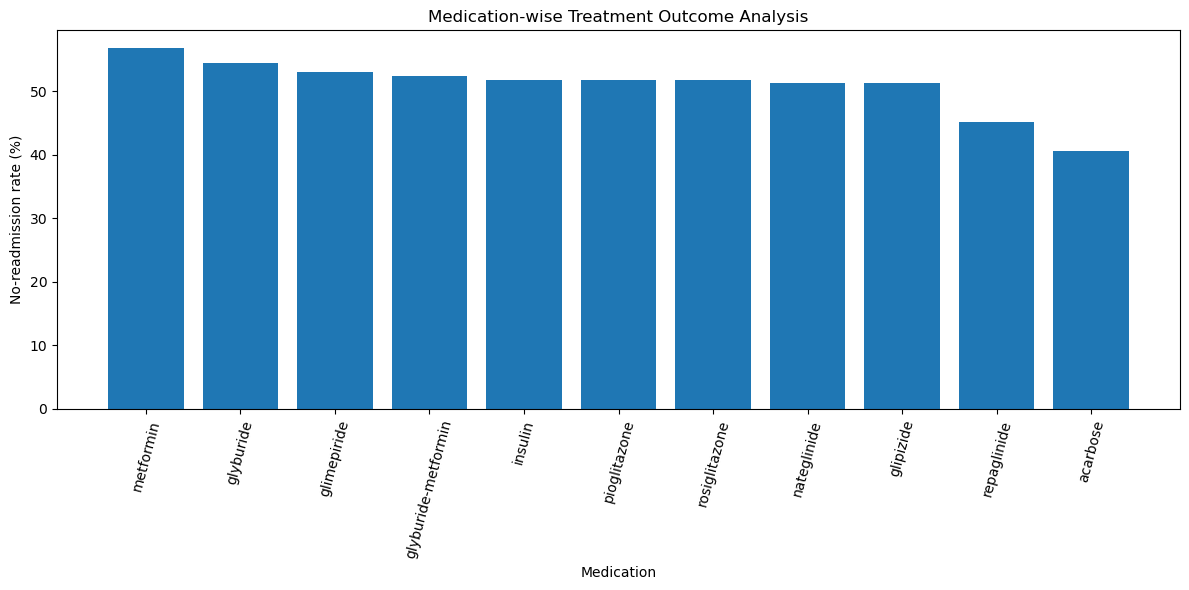

In [14]:
plt.figure(figsize=(12, 6))

plt.bar(
    reliable_medication_analysis["medication"],
    reliable_medication_analysis["outcome_rate"]
)

plt.xlabel("Medication")
plt.ylabel("No-readmission rate (%)")
plt.title("Medication-wise Treatment Outcome Analysis")
plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

# Treatment effectiveness score

In [15]:
overall_no_readmission_rate = (
    (df["readmitted"] == "NO").mean() * 100
)

reliable_medication_analysis["effectiveness_gap"] = (
    reliable_medication_analysis["no_readmission_rate"]
    - overall_no_readmission_rate
)

print(
    f"Overall no-readmission rate: "
    f"{overall_no_readmission_rate:.2f}%"
)

reliable_medication_analysis[
    [
        "medication",
        "total_patients",
        "no_readmission_rate",
        "effectiveness_gap",
    ]
].sort_values(
    "effectiveness_gap",
    ascending=False
)

Overall no-readmission rate: 53.91%


,medication,total_patients,no_readmission_rate,effectiveness_gap
0,metformin,19988,56.749049,2.837134
7,glyburide,10650,54.460094,0.548178
4,glimepiride,5191,53.053362,-0.858554
16,glyburide-metformin,706,52.407932,-1.503984
15,insulin,54383,51.828696,-2.083219
9,pioglitazone,7328,51.814956,-2.096959
10,rosiglitazone,6365,51.704635,-2.207281
2,nateglinide,703,51.351351,-2.560564
6,glipizide,12686,51.269116,-2.642800
1,repaglinide,1539,45.094217,-8.817699


# outcome distribution chart

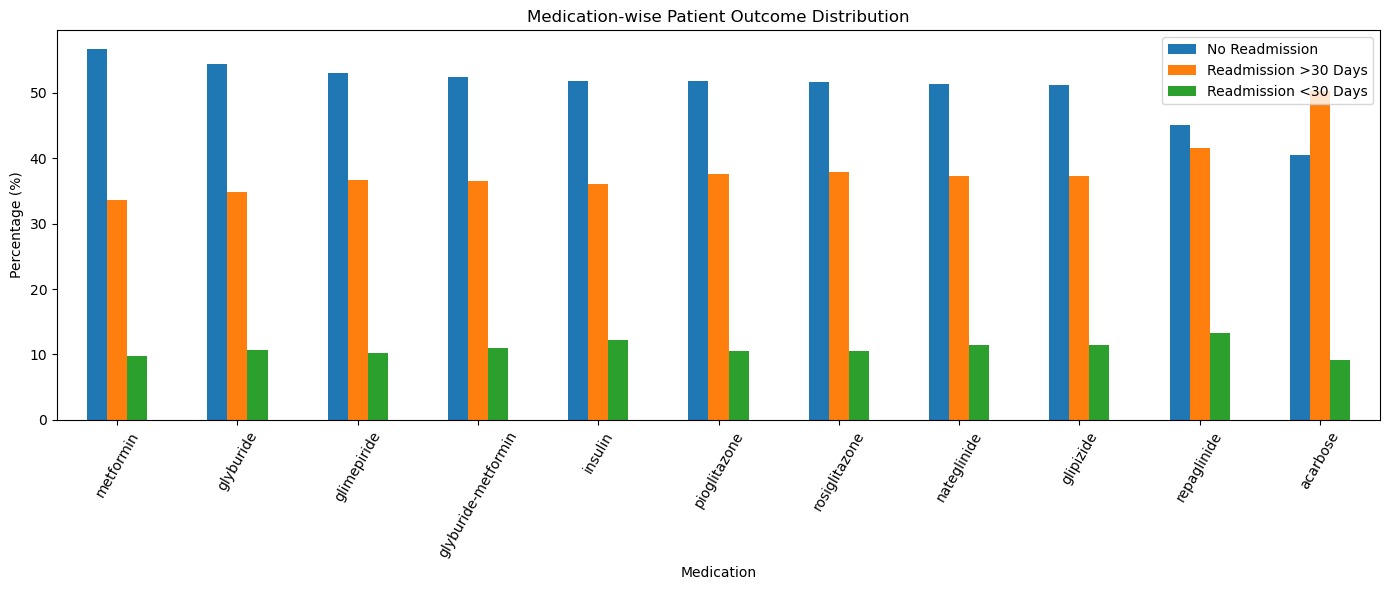

In [16]:
plot_df = reliable_medication_analysis.sort_values(
    "no_readmission_rate",
    ascending=False
)

plot_df = plot_df.set_index("medication")[
    [
        "no_readmission_rate",
        "readmission_30_plus_rate",
        "readmission_under_30_rate",
    ]
]

plot_df.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.xlabel("Medication")
plt.ylabel("Percentage (%)")
plt.title("Medication-wise Patient Outcome Distribution")
plt.xticks(rotation=60)
plt.legend(
    [
        "No Readmission",
        "Readmission >30 Days",
        "Readmission <30 Days",
    ]
)
plt.tight_layout()
plt.show()

# Medical treatment change analysis

In [18]:
print(df["change"].value_counts(dropna=False))
print()
print(df["diabetesMed"].value_counts(dropna=False))

change
No    54755
Ch    47011
Name: count, dtype: int64

diabetesMed
Yes    78363
No     23403
Name: count, dtype: int64


# change vs outcome

In [19]:
change_outcome = pd.crosstab(
    df["change"],
    df["readmitted"],
    normalize="index"
) * 100

change_outcome

readmitted,<30,>30,NO
change,,,
Ch,11.822765,36.740337,51.436898
No,10.590814,33.372295,56.036892


# clean visualization

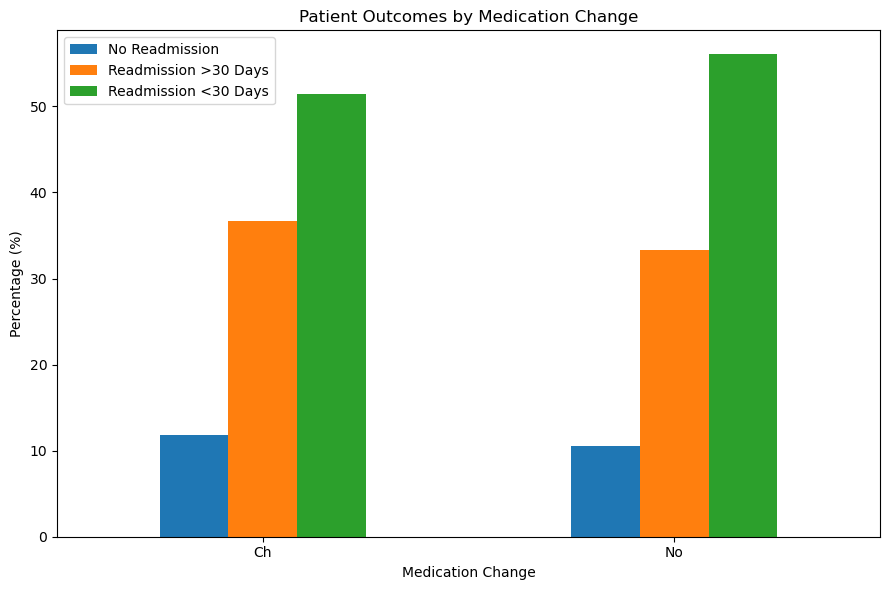

In [20]:
ax = change_outcome.plot(
    kind="bar",
    figsize=(9, 6)
)

ax.set_xlabel("Medication Change")
ax.set_ylabel("Percentage (%)")
ax.set_title("Patient Outcomes by Medication Change")
ax.legend([
    "No Readmission",
    "Readmission >30 Days",
    "Readmission <30 Days",
])

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# final treatment effectiveness summary

In [21]:
treatment_summary = reliable_medication_analysis[
    [
        "medication",
        "total_patients",
        "no_readmission_rate",
        "readmission_30_plus_rate",
        "readmission_under_30_rate",
        "effectiveness_gap",
    ]
].copy()

treatment_summary.columns = [
    "Treatment",
    "Patients",
    "No_Readmission_Rate",
    "Readmission_After_30_Rate",
    "Readmission_Under_30_Rate",
    "Baseline_Gap",
]

treatment_summary

,Treatment,Patients,No_Readmission_Rate,Readmission_After_30_Rate,Readmission_Under_30_Rate,Baseline_Gap
0,metformin,19988,56.749049,33.550130,9.700820,2.837134
7,glyburide,10650,54.460094,34.910798,10.629108,0.548178
4,glimepiride,5191,53.053362,36.736660,10.209979,-0.858554
16,glyburide-metformin,706,52.407932,36.543909,11.048159,-1.503984
15,insulin,54383,51.828696,36.033319,12.137984,-2.083219
9,pioglitazone,7328,51.814956,37.622817,10.562227,-2.096959
10,rosiglitazone,6365,51.704635,37.847604,10.447761,-2.207281
2,nateglinide,703,51.351351,37.268848,11.379801,-2.560564
6,glipizide,12686,51.269116,37.285196,11.445688,-2.642800
1,repaglinide,1539,45.094217,41.585445,13.320338,-8.817699


# Recovery / Patient Outcome Analysis

In [22]:
# Patient-level outcome indicators

df["no_readmission"] = (df["readmitted"] == "NO").astype(int)
df["readmitted_after_30"] = (df["readmitted"] == ">30").astype(int)
df["readmitted_under_30"] = (df["readmitted"] == "<30").astype(int)

print(df[
    [
        "no_readmission",
        "readmitted_after_30",
        "readmitted_under_30"
    ]
].sum())

no_readmission         54864
readmitted_after_30    35545
readmitted_under_30    11357
dtype: int64


# recovery related clinical indicator

In [24]:
recovery_features = [
    "time_in_hospital",
    "number_inpatient",
    "number_emergency",
    "number_outpatient",
    "num_medications",
    "num_lab_procedures",
    "num_procedures",
    "number_diagnoses",
]

df[recovery_features].describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,101766.0,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0
number_inpatient,101766.0,0.635566,1.262863,0.0,0.0,0.0,1.0,21.0
number_emergency,101766.0,0.197836,0.930472,0.0,0.0,0.0,0.0,76.0
number_outpatient,101766.0,0.369357,1.267265,0.0,0.0,0.0,0.0,42.0
num_medications,101766.0,16.021844,8.127566,1.0,10.0,15.0,20.0,81.0
num_lab_procedures,101766.0,43.095641,19.674362,1.0,31.0,44.0,57.0,132.0
num_procedures,101766.0,1.339730,1.705807,0.0,0.0,1.0,2.0,6.0
number_diagnoses,101766.0,7.422607,1.933600,1.0,6.0,8.0,9.0,16.0


In [25]:
recovery_by_outcome = (
    df.groupby("readmitted")[recovery_features]
    .mean()
    .round(2)
)

recovery_by_outcome

,time_in_hospital,number_inpatient,number_emergency,number_outpatient,num_medications,num_lab_procedures,num_procedures,number_diagnoses
readmitted,,,,,,,,
<30,4.77,1.22,0.36,0.44,16.90,44.23,1.28,7.69
>30,4.50,0.84,0.28,0.50,16.28,43.84,1.25,7.65
NO,4.25,0.38,0.11,0.27,15.67,42.38,1.41,7.22


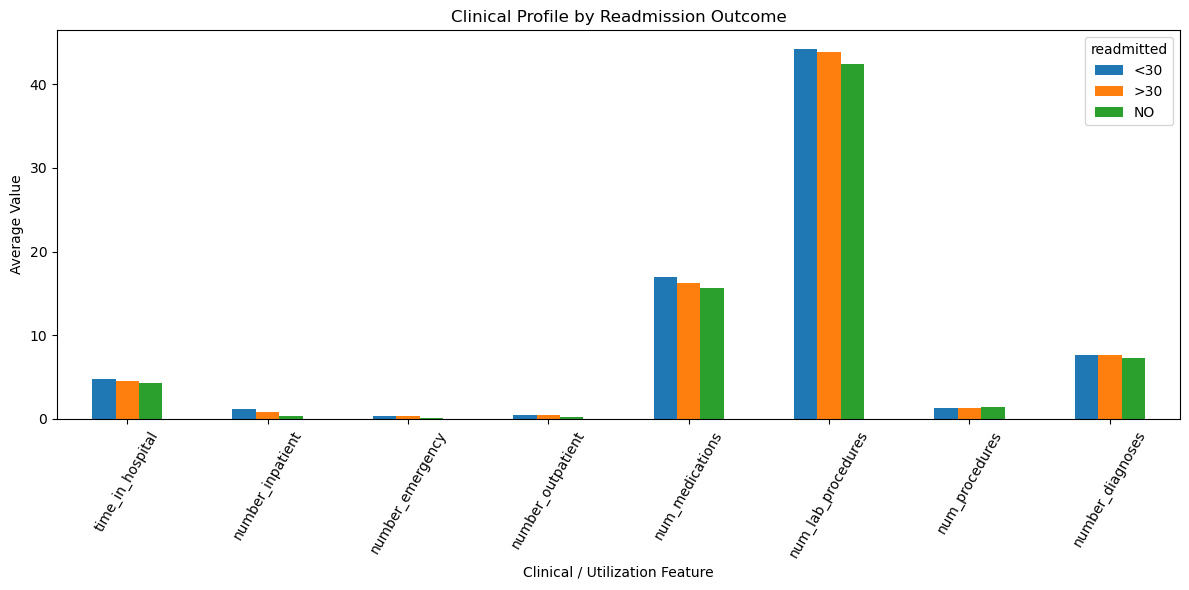

In [26]:
ax = recovery_by_outcome.T.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_xlabel("Clinical / Utilization Feature")
ax.set_ylabel("Average Value")
ax.set_title("Clinical Profile by Readmission Outcome")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


In [27]:
def classify_outcome(readmitted):
    if readmitted == "NO":
        return "No Readmission"
    elif readmitted == ">30":
        return "Readmitted After 30 Days"
    elif readmitted == "<30":
        return "Readmitted Within 30 Days"
    return "Unknown"


df["outcome_status"] = df["readmitted"].apply(classify_outcome)

df["outcome_status"].value_counts()

outcome_status
No Readmission               54864
Readmitted After 30 Days     35545
Readmitted Within 30 Days    11357
Name: count, dtype: int64

# outcome percentage

In [28]:
outcome_summary = (
    df["outcome_status"]
    .value_counts()
    .rename_axis("outcome_status")
    .reset_index(name="patient_count")
)

outcome_summary["percentage"] = (
    outcome_summary["patient_count"]
    / outcome_summary["patient_count"].sum()
    * 100
).round(2)

outcome_summary

,outcome_status,patient_count,percentage
0,No Readmission,54864,53.91
1,Readmitted After 30 Days,35545,34.93
2,Readmitted Within 30 Days,11357,11.16


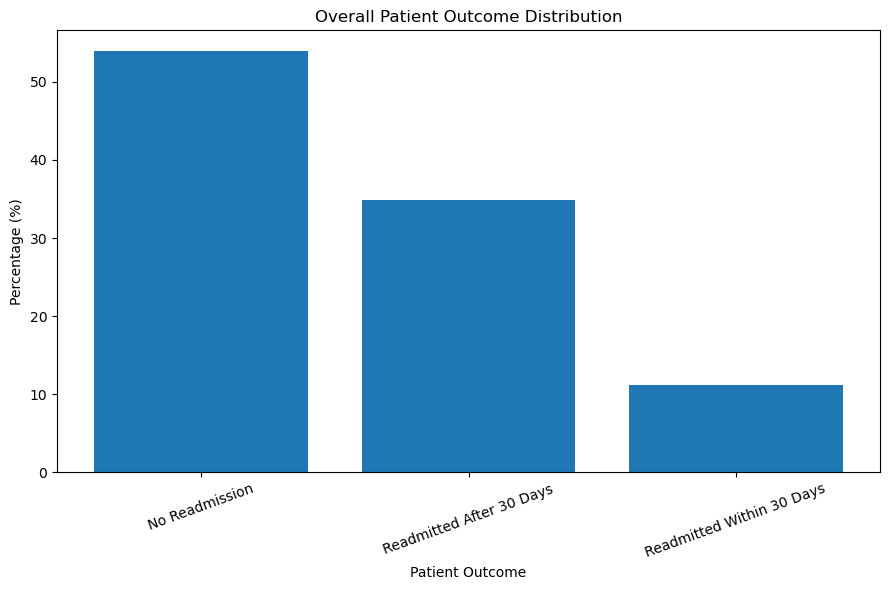

In [29]:
plt.figure(figsize=(9, 6))

plt.bar(
    outcome_summary["outcome_status"],
    outcome_summary["percentage"]
)

plt.xlabel("Patient Outcome")
plt.ylabel("Percentage (%)")
plt.title("Overall Patient Outcome Distribution")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [30]:
outcome_profile = (
    df.groupby("outcome_status")[recovery_features]
    .mean()
    .round(2)
)

outcome_profile



,time_in_hospital,number_inpatient,number_emergency,number_outpatient,num_medications,num_lab_procedures,num_procedures,number_diagnoses
outcome_status,,,,,,,,
No Readmission,4.25,0.38,0.11,0.27,15.67,42.38,1.41,7.22
Readmitted After 30 Days,4.50,0.84,0.28,0.50,16.28,43.84,1.25,7.65
Readmitted Within 30 Days,4.77,1.22,0.36,0.44,16.90,44.23,1.28,7.69


In [31]:
import joblib

MODEL_PATH = "../artifacts/readmission_model.joblib"

risk_model = joblib.load(MODEL_PATH)

print("Model loaded successfully!")
print(type(risk_model))


Model loaded successfully!
<class 'sklearn.pipeline.Pipeline'>


# expected features of model

In [33]:
print(risk_model.named_steps)

{'preprocess': ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['admission_type_id',
                                  'discharge_disposition_id',
                                  'admission_source_id', 'time_in_hospital',
                                  'num_lab_procedures', 'num_procedures',
                                  'num_medications', 'number_outpatient',
                                  'number_emergency', 'number_inpatient',
                                  'number_diagnos...
                                  'diag_3', 'max_glu_serum', 'A1Cresult',
                                  'metformin', 'repaglinide', 'nateglinide',
                                  'chlorpropamide', 'glimepiride',
                             

In [34]:
for name, step in risk_model.named_steps.items():
    print(name, "->", type(step))

preprocess -> <class 'sklearn.compose._column_transformer.ColumnTransformer'>
model -> <class 'xgboost.sklearn.XGBClassifier'>


In [35]:
preprocessor = risk_model.named_steps["preprocess"]

expected_features = list(preprocessor.feature_names_in_)

print("Number of expected input columns:", len(expected_features))
print("\nExpected columns:")
for i, col in enumerate(expected_features, start=1):
    print(f"{i}. {col}")


Number of expected input columns: 45

Expected columns:
1. race
2. gender
3. age
4. admission_type_id
5. discharge_disposition_id
6. admission_source_id
7. time_in_hospital
8. num_lab_procedures
9. num_procedures
10. num_medications
11. number_outpatient
12. number_emergency
13. number_inpatient
14. diag_1
15. diag_2
16. diag_3
17. number_diagnoses
18. max_glu_serum
19. A1Cresult
20. metformin
21. repaglinide
22. nateglinide
23. chlorpropamide
24. glimepiride
25. acetohexamide
26. glipizide
27. glyburide
28. tolbutamide
29. pioglitazone
30. rosiglitazone
31. acarbose
32. miglitol
33. troglitazone
34. tolazamide
35. examide
36. citoglipton
37. insulin
38. glyburide-metformin
39. glipizide-metformin
40. glimepiride-pioglitazone
41. metformin-rosiglitazone
42. metformin-pioglitazone
43. change
44. diabetesMed
45. prior_visits_total


# model vs dataset check

In [36]:
missing_features = [
    col for col in expected_features
    if col not in df.columns
]

extra_features = [
    col for col in df.columns
    if col not in expected_features
]

print("Missing features:", missing_features)
print("Number of missing features:", len(missing_features))

print("\nExtra dataset columns:", extra_features)
print("Number of extra columns:", len(extra_features))

Missing features: ['prior_visits_total']
Number of missing features: 1

Extra dataset columns: ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty', 'readmitted', 'no_readmission', 'readmitted_after_30', 'readmitted_under_30', 'outcome_status']
Number of extra columns: 10


In [37]:
utilisation_columns = [
    "number_outpatient",
    "number_emergency",
    "number_inpatient"
]

df["prior_visits_total"] = df[utilisation_columns].sum(axis=1)

print("prior_visits_total created successfully!")
print(df["prior_visits_total"].describe())

prior_visits_total created successfully!
count    101766.000000
mean          1.202759
std           2.291781
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max          80.000000
Name: prior_visits_total, dtype: float64


In [38]:
missing_features = [
    col for col in expected_features
    if col not in df.columns
]

print("Missing features:", missing_features)
print("Number of missing features:", len(missing_features))

Missing features: []
Number of missing features: 0


In [39]:
X_risk = df[expected_features].copy()

risk_probability = risk_model.predict_proba(X_risk)[:, 1]

df["risk_probability"] = risk_probability

print(df["risk_probability"].describe())

count    101766.000000
mean          0.453267
std           0.130704
min           0.100651
25%           0.353042
50%           0.449101
75%           0.539834
max           0.921977
Name: risk_probability, dtype: float64


In [40]:
def assign_risk_band(probability):
    if probability >= 0.70:
        return "High"
    elif probability >= 0.40:
        return "Medium"
    else:
        return "Low"


df["risk_band"] = df["risk_probability"].apply(assign_risk_band)

print(df["risk_band"].value_counts())

risk_band
Medium    60435
Low       37664
High       3667
Name: count, dtype: int64


In [41]:
risk_outcome_analysis = pd.crosstab(
    df["risk_band"],
    df["readmitted"],
    normalize="index"
) * 100

risk_outcome_analysis = risk_outcome_analysis.round(2)

risk_outcome_analysis

readmitted,<30,>30,NO
risk_band,,,
High,43.80,37.25,18.95
Low,4.43,28.36,67.21
Medium,13.37,38.88,47.75


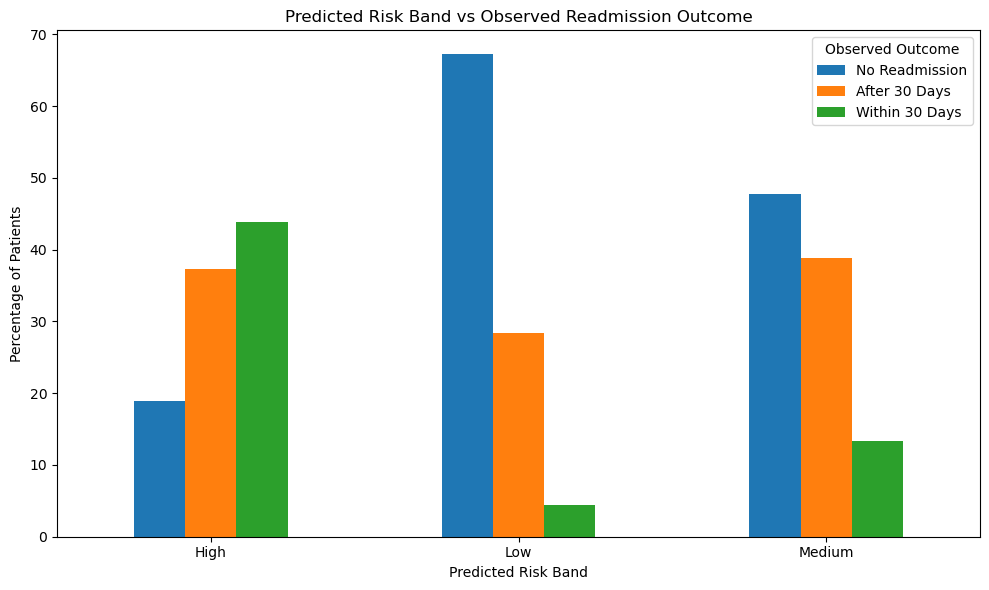

In [42]:
risk_outcome_plot = risk_outcome_analysis[
    ["NO", ">30", "<30"]
]

ax = risk_outcome_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_xlabel("Predicted Risk Band")
ax.set_ylabel("Percentage of Patients")
ax.set_title("Predicted Risk Band vs Observed Readmission Outcome")
plt.xticks(rotation=0)
plt.legend(
    title="Observed Outcome",
    labels=["No Readmission", "After 30 Days", "Within 30 Days"]
)
plt.tight_layout()
plt.show()

In [43]:
risk_treatment_summary = []

for medication in available_medications:
    medication_mask = ~df[medication].isin(["No", ""])

    medication_df = df.loc[medication_mask].copy()

    if len(medication_df) == 0:
        continue

    summary = (
        medication_df
        .groupby("risk_band")
        .agg(
            patients=("risk_band", "size"),
            no_readmission=("no_readmission", "mean"),
            readmitted_under_30=("readmitted_under_30", "mean")
        )
        .reset_index()
    )

    summary["medication"] = medication

    risk_treatment_summary.append(summary)

risk_treatment_df = pd.concat(
    risk_treatment_summary,
    ignore_index=True
)

risk_treatment_df["no_readmission"] *= 100
risk_treatment_df["readmitted_under_30"] *= 100

risk_treatment_df.round(2)

,risk_band,patients,no_readmission,readmitted_under_30,medication
0,High,409,19.80,51.83,metformin
1,Low,8797,67.42,4.08,metformin
2,Medium,10782,49.44,12.69,metformin
3,High,49,14.29,51.02,repaglinide
4,Low,318,58.81,5.66,repaglinide
5,Medium,1172,42.66,13.82,repaglinide
6,High,13,15.38,69.23,nateglinide
7,Low,238,65.97,4.20,nateglinide
8,Medium,452,44.69,13.50,nateglinide
9,High,1,100.00,0.00,chlorpropamide


In [44]:
reliable_risk_treatment = risk_treatment_df[
    risk_treatment_df["patients"] >= 100
].copy()

reliable_risk_treatment = reliable_risk_treatment.sort_values(
    ["medication", "risk_band"]
)

reliable_risk_treatment.round(2)

,risk_band,patients,no_readmission,readmitted_under_30,medication
31,Low,112,52.68,1.79,acarbose
32,Medium,191,34.55,12.57,acarbose
12,High,119,15.13,52.10,glimepiride
13,Low,2427,64.07,3.91,glimepiride
14,Medium,2645,44.65,14.10,glimepiride
16,High,353,22.10,41.93,glipizide
17,Low,4237,63.94,4.63,glipizide
18,Medium,8096,45.91,13.69,glipizide
19,High,191,18.85,52.88,glyburide
20,Low,3795,65.51,5.01,glyburide


In [45]:
major_medications = [
    "insulin",
    "metformin",
    "glipizide",
    "glyburide",
    "pioglitazone",
    "rosiglitazone",
    "glimepiride",
    "repaglinide"
]

major_risk_treatment = reliable_risk_treatment[
    reliable_risk_treatment["medication"].isin(major_medications)
].copy()

major_risk_treatment

,risk_band,patients,no_readmission,readmitted_under_30,medication
12,High,119,15.126050,52.100840,glimepiride
13,Low,2427,64.070869,3.914297,glimepiride
14,Medium,2645,44.650284,14.102079,glimepiride
16,High,353,22.096317,41.926346,glipizide
17,Low,4237,63.936748,4.625915,glipizide
18,Medium,8096,45.911561,13.685771,glipizide
19,High,191,18.848168,52.879581,glyburide
20,Low,3795,65.507246,5.006588,glyburide
21,Medium,6664,49.189676,12.620048,glyburide
39,High,2579,18.844513,42.613416,insulin
